xcb_connection_has_error() returned true
xcb_connection_has_error() returned true
ALSA lib pulse.c:243:(pulse_connect) PulseAudio: Unable to connect: Connection refused

xcb_connection_has_error() returned true
xcb_connection_has_error() returned true
ALSA lib pulse.c:243:(pulse_connect) PulseAudio: Unable to connect: Connection refused



Opened 2 videos from /home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos
Stacking videos with duration 1.05 seconds each
Moviepy - Building video /home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/stacked_videos.mp4.
Moviepy - Writing video /home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/stacked_videos.mp4



Moviepy - Done !
Moviepy - video ready /home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/stacked_videos.mp4


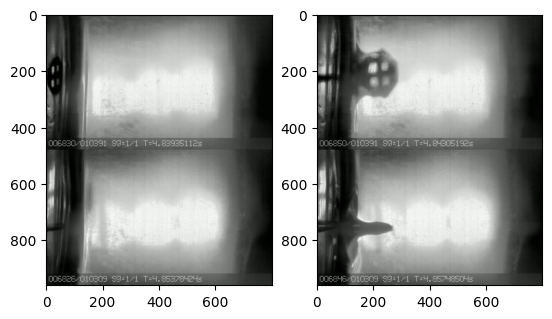

In [1]:
import os 
from moviepy.editor import VideoFileClip, clips_array
from moviepy.editor import VideoFileClip, clips_array
import matplotlib.pyplot as plt
import cv2

# Load the videos
video_paths_full = [
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/enhanced_video_silicon_chip_clip5_oldSiChip_front_vid_2025-07-21_18-43-57.mp4",
    "/home/abharadwaj1/dev/plunger_heat_transfer/analyse_cavity_closing/silicon_chip/enhanced_videos/enhanced_video_silicon_chip_clip5_oldSiChip_side_vid_2025-07-21_18-39-26.mp4"
]
parent_folder = os.path.dirname(video_paths_full[0])

videos = [VideoFileClip(path) for path in video_paths_full]
print(f"Opened {len(videos)} videos from {parent_folder}")
# Calculate starting frames for each video
start_frames = [0, 0]

# Correct FPS and calculate the number of frames
fps = 60
num_frames = cv2.VideoCapture(video_paths_full[0]).get(cv2.CAP_PROP_FRAME_COUNT)-1
duration = num_frames / fps  # duration in seconds

# Stack the videos vertically
print(f"Stacking videos with duration {duration} seconds each")
clipped_videos = [video.subclip(start, start + duration) for video, start in zip(videos, start_frames)]
stacked_video = clips_array([[clipped_videos[0]], [clipped_videos[1]]])

# Output the stacked video to a file

stacked_video_path = os.path.join(parent_folder,f"stacked_videos.mp4")
if os.path.exists(stacked_video_path):
    os.remove(stacked_video_path)
stacked_video.write_videofile(stacked_video_path, codec="libx264")

frame_1 = stacked_video.get_frame(0)
frame_20 = stacked_video.get_frame(20/fps)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(frame_1)
ax[1].imshow(frame_20)
